In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [2]:
test_Teq = 800
test_comp = 'EL3'
thresh_cond = 1e-6

In [3]:
chem = pd.read_csv(f'output/grid_day/{test_Teq}K_{test_comp}_day/chemistry/chem_best.dat', sep='\\s+')
cond = pd.read_csv(f'output/grid_day/{test_Teq}K_{test_comp}_day/chemistry/condensates_best.dat', sep='\\s+')

In [4]:
if "#p(bar)" in cond.columns:
    cond.rename(columns={"#p(bar)": "p(bar)"}, inplace=True)

In [5]:
def formula_contains(formula, element):
    """Check if the formula contains a specific element."""
    idx = formula.find(element)
    while idx != -1:
        after = idx + len(element)
        if (after == len(formula)) or (not formula[after].islower()):
            return True
        idx = formula.find(element, idx + 1)
    return False

In [6]:
# Get columns that have '(s)', '(l)', or '(s,l)' in the name
cond_columns = [col for col in cond.columns if '(s)' in col or '(l)' in col or '(s,l)' in col]

In [7]:
cond['total_condensate_abundance'] = cond[cond_columns].sum(axis=1)

In [8]:
#split into columns that are present at the bottom of the atmosphere and those that aren't
#first, just list the condensates that are present at the bottom of the atmosphere by fraction of total condensate abundance
#sort cond_columns by abundance at the bottom of the atmosphere
cond_columns_sorted = sorted(cond_columns, key=lambda col: cond[col].iloc[0], reverse=True)
print("Condensates sorted by abundance at the bottom of the atmosphere:")
for col in cond_columns_sorted:
    abundance = cond[col].iloc[0]
    fraction = abundance / cond['total_condensate_abundance'].iloc[0] if cond['total_condensate_abundance'].iloc[0] > 0 else 0
    print(f"{col}: abundance = {abundance:.2e}, fraction of total = {fraction:.2e}")

Condensates sorted by abundance at the bottom of the atmosphere:
MgSiO3(s,l): abundance = 7.39e+19, fraction of total = 4.87e-01
Fe(s,l): abundance = 5.82e+19, fraction of total = 3.84e-01
FeS(s,l): abundance = 9.75e+18, fraction of total = 6.43e-02
NaAlSi3O8(s): abundance = 3.51e+18, fraction of total = 2.32e-02
CaMgSi2O6(s): abundance = 2.16e+18, fraction of total = 1.43e-02
C(s): abundance = 1.55e+18, fraction of total = 1.02e-02
Ni3S2(s,l): abundance = 1.36e+18, fraction of total = 9.00e-03
KAlSi3O8(s): abundance = 3.34e+17, fraction of total = 2.20e-03
MnS(s): abundance = 2.69e+17, fraction of total = 1.77e-03
Co(s,l): abundance = 2.31e+17, fraction of total = 1.52e-03
Al6Si2O13(s): abundance = 1.83e+17, fraction of total = 1.20e-03
Cr3C2(s): abundance = 1.55e+17, fraction of total = 1.02e-03
SiO2(s,l): abundance = 4.74e+16, fraction of total = 3.13e-04
Ti3O5(s,l): abundance = 4.11e+16, fraction of total = 2.71e-04
Al(s): abundance = 0.00e+00, fraction of total = 0.00e+00
AlClO(s)

In [9]:
# just select visible condensates
cond_columns_vis = [col for col in cond_columns if (cond[col]/cond['total_condensate_abundance']).max() > thresh_cond]

In [10]:
# split condensates into those that are present at the bottom of the atmosphere and those that aren't
cond_columns_sed = [col for col in cond_columns_vis if cond[col].iloc[0] > 0]
cond_columns_no_sed = [col for col in cond_columns_vis if cond[col].iloc[0] == 0]

In [11]:
groups = [("Present at Surface",cond_columns_sed), ("Not Present at Surface",cond_columns_no_sed)]

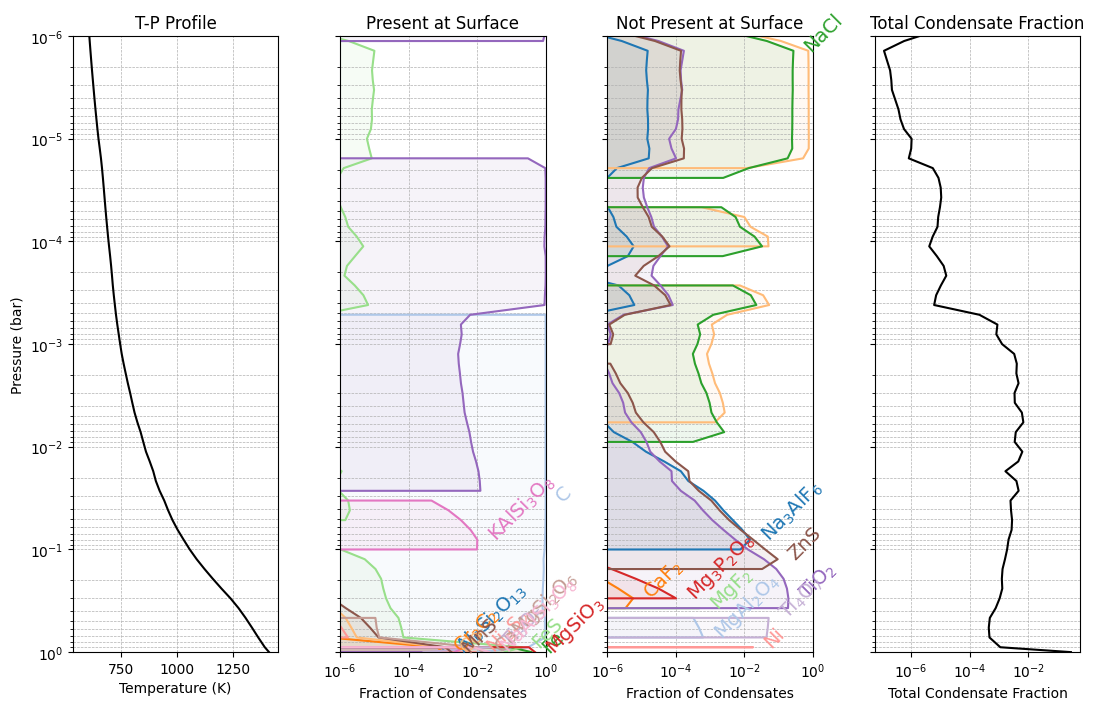

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(13, 8), sharey=True)
plt.subplots_adjust(wspace=0.3)

#T-P profile
ax = axes[0]
ax.plot(cond['T(K)'], cond['p(bar)'], color='black')
ax.set_yscale('log')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Pressure (bar)')
ax.set_title('T-P Profile')
ax.grid(True, which='both', ls='--', lw=0.5)

for ax, (title, columns) in zip(axes[1:3], groups):
    cmap = plt.get_cmap('tab10') if len(columns) <= 10 else plt.get_cmap('tab20')
    color_list = [cmap(i % cmap.N) for i in range(len(columns))]
    for i,col in enumerate(columns):
        label = col.split('(')[0].strip()
        # replace element-number sequences (including multi-digit numbers) with subscript mathtext
        label = re.sub(r'([A-Za-z\)])(\d+)', lambda m: f"{m.group(1)}$_{{{m.group(2)}}}$", label)
        y = cond['p(bar)']
        x = cond[col] / cond['total_condensate_abundance']
        ax.plot(x, y, label=label, color=color_list[i])
        ax.fill_betweenx(y, 0, x, color=color_list[i], alpha=0.08)
        #find the highest x at which the condensate appears
        index_appears = x.idxmax()
        ax.annotate(label, xy=(x[index_appears], y[index_appears]), xytext=(5, 0), textcoords='offset points', fontsize=14, color=color_list[i], rotation=45)
    ax.set_xscale('log')
    ax.set_xlim(1e-6,1e0)
    ax.set_yscale('log')
    ax.set_ylim(1e0, 1e-6)
    ax.set_xlabel('Fraction of Condensates')
    ax.set_title(title)
    ax.grid(True, which='both', ls='--', lw=0.5)

ax = axes[3]
ax.plot( cond['total_condensate_abundance']/chem['n_<tot>(cm-3)'], cond['p(bar)'], color='black')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Total Condensate Fraction')
ax.set_title('Total Condensate Fraction')
ax.grid(True, which='both', ls='--', lw=0.5)

In [20]:
(chem['n_<tot>(cm-3)'] - cond['total_condensate_abundance']) / chem['n_g(cm-3)']

0     23.507883
1      2.678471
2      2.671045
3      2.665600
4      2.660438
        ...    
70     2.752291
71     2.751626
72     2.750860
73     2.749923
74     2.749884
Length: 75, dtype: float64

In [21]:
cond['total_condensate_abundance'] / chem['n_<tot>(cm-3)']

0     2.245488e-01
1     2.251233e-04
2     3.041003e-09
3     6.086276e-09
4     8.754105e-09
          ...     
70    7.938618e-13
71    5.274376e-13
72    3.425526e-13
73    1.536754e-13
74    1.231075e-12
Length: 75, dtype: float64

In [22]:
np.sum(cond['total_condensate_abundance'] / np.sum(chem['n_<tot>(cm-3)']))

np.float64(0.1594513589092657)